# IS 470 Assignment 2: Voting Behavior

This assignment will help you understand how machine learning (ML) models such as Decision Tree (DT), Naïve Bayes (NB), and K-Nearest Neighbor (KNN), are used to solve real-world business problems such as predicting voting behavior. You’ll explore a dataset, build classification models, and evaluate their performance. This foundational project builds your skills for future assignments and gives you hands-on experience relevant to careers in data science, analytics, and business intelligence.

In [1]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import libraries
import pandas as pd               # used for data analysis and manipulation

# import numpy as np              # pandas depends on numpy but we are not using numpy directly so I am commenting this out for clarity

import seaborn as sns             # used for data visualization (used for lots of charts, box plot, scatter plot etc...)
import matplotlib.pyplot as plt   # used for data visualization (specifically for plotting the decision tree classifier)

# note, previously we were importing specific module functions from sklearn.  This is not necessary since internally they do not have any naming conflicts
import sklearn as sk              # used for a bunch of things, DecisionTreeClassifier and more.



In [3]:
voting_behavior = pd.read_excel('/content/drive/MyDrive/IS470_data/Gaming Ballot Dataset.xls')
# Note, showing first 16 columns so that i can actually read it on my screen
voting_behavior.iloc[:, :16].head()

,State No,County No,FOR,AGAINST,TOTAL CASTE,DEPENDENT VARIABLE,BALLOT TYPE,POPULATION,PCI,MEDIUM FAMILY INCOME,SIZE OF COUNTY,POPULATION DENSITY,PERCENT WHITE,PERCENT BLACK,PERCENT OTHER,PERCENT MALE
0,1,1,42385,22992,65377,1,1,265038,15607,34618,1192.0,223.29,0.75,0.03,0.22,0.496
1,1,2,2015,1852,3867,1,1,13617,13740,23114,722.8,18.81,0.59,0.00,0.40,0.491
2,1,3,51959,48406,100365,1,1,391511,24187,44874,803.2,490.34,0.85,0.06,0.09,0.488
3,1,4,957,856,1813,1,1,5345,12816,27359,1349.4,3.99,0.74,0.00,0.26,0.510
4,1,5,942,1129,2071,0,1,4556,19017,23054,2555.9,1.77,0.93,0.00,0.07,0.495


In [4]:
# and here are the remaining columns
voting_behavior.iloc[:, 16:].head()

,PERCENT FEMALE,NO OF CHURCHES,NO OF CHURCH MEMBERS,PERCENT CHURCH MEMBERS OF POPULATION,POVERTY LEVEL,UNEMPLOYMENT RATE,AGE LESS THAN 18,AGE24,AGE44,AGE64,AGE OLDER THAN 65,MSA,PERCENT MINORITY,NO OF OLDER,NO OF YOUNGER
0,0.504,128,25110.0,0.094340,10.4,5.0,80600,22627,94724,46933,20154,1,0.25,67087,189448
1,0.509,22,2427.0,0.178522,24.8,7.0,4285,1861,4092,2114,1265,2,0.40,3379,8184
2,0.512,180,58252.0,0.147909,5.9,3.0,111243,29574,150740,70783,29171,1,0.15,99954,301480
3,0.490,14,1151.0,0.213821,16.9,5.0,1647,229,1670,1178,621,2,0.26,1799,3340
4,0.505,23,982.0,0.217305,19.0,1.0,1192,220,1231,973,940,2,0.07,1913,2462


## Business Understanding

Core understanding:  This dataset is regarding a public ballot measure about weather gambling should be made legal or not.  One of the interesting parameters is Ballot Type, which is either set to Gambline or Wagering (see definition below).  My assumption here is they are trying to determine weather gambling or wagering should be allowed and the likelyhood that people would vote for it if it were proposed.

### Basic principles of voting behavior<br>
(this is generic and not specific to this particular situation)

Sociological Factors:

  * Social class: working class may lean left, wealthy tend to lean right
  * Religion: Religious affiliation correlates with political preference
  * Ethnicity: Minority groups tend to vote for certain parties
  * Region: Certain areas may have distinct political cultures and patterns
  * Education: Higher education levels influence ideology

Psychological Factors:

  * Party identification: A long-term pyschological attachment is a strong predictor
  * Candidate Image: personal traits of candidates affect voters
  * Issue Voting: people tend to vote for candidates that support certain issues
  * Perceived performance: Rewards or punishments for incumbents

Other Factors:
  * Turnout: is a major factor tending to go one way or another as voting increases
  * Media influence: is also very important
  * Retrospective vs Prospective: Votes based on past performance or future promises.

### How related industries might be affected

Depending on how it is implemented, there are certainly other industries that might be affected.  For example, if wagering were allowed on sporting events, then this could potentially increase participation in those events.  This could be good for the venues which host those events as well as surrounding businesses.  On the other hand if pure gambling were allowed then this might give rise to casios (which might have a similar impact on the neighborhood)

That said, there are also probably bad side effects.  For example if casinos are allowed, what effect does this have on local traffic and property values.  All of those things should be taken into consideration.

To understand exactly how these choices affects a neighborhood and community is difficult, but it is foreseeable that you could make some predictions on this depending on what data you have at hand (I do not know yet if we have enough data to make these kinds of predictions however)

## Data Understanding
**State and County No:**  These numbers represent states or counties (important, they are categorical not numeric)</br>
**For and Against:**  The count of voters for or against<br/>
**Total Caste:**  Sum of the previous two numbers, (highly correlated)<br/>
**Dependent Variable:**  This is the target variable<br/>
**Ballot Type:**  Gambling or Wagering refers to weather or not there is skill involved in the transaction.  Betting on a die roll for example would be gambling, where betting on a football game would be wagering<br/>
**Population:**  (assuming of the county)<br/>
**PCI:**  Per-Capita Income?<br/>
**Medium Family Income:**  Seems pretty obvious<br/>
**Size of County:**  In what? Square miles?<br/>
**Population Density:**  Seems like this is related to Size and Population<br/>
**Percent White:** White <br/>
**Percent Black:** Black <br/>
**Percent Other:** Other <br/>
**Percent Male:** Male <br/>
**Percent Female:** Female <br/>
**No Of Churches:** # of Churches <br/>
**No Of Church Members:** # of Church Members <br/>
**Percent Church Members of Population:** Highly correlated to other data <br/>
**Poverty Level:** percentage of population? <br/>
**Unemployment Rate:** percentage of people in the labor force looking for work<br/>
**Age Less Than 18:** Children <br/>
**Age24:** I'm guessing between 18 and 24<br/>
**Age44:** I'm guessing between 24 and 44<br/>
**Age64:** I'm guessing between 44 and 64<br/>
**Age Older than 65:** Senior Citizens<br/>
**MSA:** Metropolitan Statistical Area (urban vs rural)<br/>
**Percent Minority:** How is this defined exactly?<br/>
**No of Older:** Number of older people (where is the cutoff?)<br/>
**No of Younger:** Again, what is the cutoff?<br/>

Note: A lot of these variables are directly correlated with one another so before we go figuring out any decision tree analysis or anything else, we might want to get rid of the useless/extra values.


## Context
Above, is a simple listing of all the variables we have, however there is not a lot of context here. For context, we need to look more closely at them.<br/>
For example.  The first variables that stand out to me are the following:
1) Ballot Type, 2) For, 3) Against, 4) Total Caste, and 5) the Dependent Variable.<br/>

I highly suspect that all 5 of these variables are directly correlated with one anther.  Total Caste is simply the For plus the Against, and the Dependent Variable may possibly be set to 0 or 1 depeding on whether For or Against has more numbers (this may also not be the case).  In order to understand better, I need to look at the statistics regarding these values closer.<br/>

Note: Ballot Type is a special case, that I will explain later, but it's also related in my opinion.

In [5]:
# question, does For + Against always = Total Caste?

# Check if 'Total Caste' is equal to 'For' + 'Against' for all rows
condition = voting_behavior['TOTAL CASTE'] == (voting_behavior['FOR'] + voting_behavior['AGAINST'])

# Print whether the condition holds for all rows
if condition.all():
    print("✅ 'TOTAL CASTE' is always the sum of 'FOR' and 'AGAINST'.")
else:
    print("❌ There are discrepancies. Here are the problematic rows:")
    print(voting_behavior[~condition])


✅ 'TOTAL CASTE' is always the sum of 'FOR' and 'AGAINST'.


Therefore, TOTAL CASTE is not necessary as it duplicates data we already have<br/>Now, lets look at the dependent variable:

In [6]:
# Create a condition based on 'For' and 'Against'
expected_dependent = (voting_behavior['FOR'] > voting_behavior['AGAINST']).astype(int)

# Check if the 'DEPENDENT VARIABLE' matches this logic
condition = voting_behavior['DEPENDENT VARIABLE'] == expected_dependent

# Print whether the condition holds for all rows
if condition.all():
    print("✅ 'DEPENDENT VARIABLE' is correctly set based on whether 'For' > 'Against'.")
else:
    print("❌ There are discrepancies. Here are the problematic rows:")
    print(voting_behavior[~condition])


✅ 'DEPENDENT VARIABLE' is correctly set based on whether 'For' > 'Against'.


This one is pretty critical.  Basically what we are saying here is that For and Against already completely predict the dependent variable.  Therefore we can not use those in our prediction (because essentially they represent information we would not have before the voting takes place)... ok, now lets look at Ballot Type:

In [7]:
print(voting_behavior['BALLOT TYPE'].value_counts())

BALLOT TYPE
2    698
1    589
Name: count, dtype: int64


Ok, Ballot Type is either 1 or 2 which works with our theory that it represents Gambling or Wagering (we don't know which is which). now lets check how that correlates with the Dependent Variable

In [8]:
group_counts = voting_behavior.groupby(['BALLOT TYPE', 'DEPENDENT VARIABLE']).size().unstack(fill_value=0)
print(group_counts)

DEPENDENT VARIABLE    0    1
BALLOT TYPE                 
1                   390  199
2                   349  349


Very interesting.  From the above analysis, I think we can conclude that For and Against should not be included in the predictors data set.  Ballot Type however is a valid value.  Total Caste, has two problems.  First, it's the combination of For and Against, therefore it is duplicate, but second and probably more important, this is a number that you would not even get till after the election.  Therefore, you won't know it in advance.  Therefore it should not be included.

Lets look at other values.  The next values in question are 1) Size of County, 2) Population and 3) Population Density.  These three values are all directly correlated.  While you could go with Size of County and Population, I would guess opting for Density would be the better option since that would give you only one variable and therefore the other variables would not be downplayed as much.  --- so, get rid of Size of County and Population as well

Per Capita Income and Median Family Income while related, are not directly related so I would include both of those.

Percent, White, Black or Other are related.  For this, I would exclude one of the values because essentially this is like a dummy codded variable which has already been dummy codded.  For our purposes I will remove 'Other'.

For similar reasons, I will also remove Female and Age over 65.  As far as I can tell all the other values may be useful.  Except MSA, I don't fully understand what that value is.  lets look at it...

In [9]:
# Examine MSA variable
print(voting_behavior['MSA'].value_counts())

MSA
2    1006
1     281
Name: count, dtype: int64


Ok, my guess is 2 represents rural and 1 represents urban.  I'm cool with that.<br>
### Summary
**State No**		Include<br/>
**County No**		Include<br/>
**FOR**			Not needed, cheating variable<br/>
**AGAINST**			Not needed, cheating variable<br/>
**TOTAL CASTE**		Not needed, data leakage<br/>
**DEPENDENT VARIABLE**  	(Target value used for training only)<br/>
**BALLOT TYPE**		Really, this is probably data leakage also, we don't know this yet<br/>
**POPULATION**		Duplicated by population density<br/>
**PCI**			Include<br/>
**MEDIUM FAMILY INCOME**	Include<br/>
**SIZE OF COUNTY**		Duplicated by population density<br/>
**POPULATION DENSITY**	Include<br/>
**PERCENT WHITE**		Include<br/>
**PERCENT BLACK**		Include<br/>
**PERCENT OTHER**		Duplicated by White/Black<br/>
**PERCENT MALE**		Include<br/>
**PERCENT FEMALE**		Duplicated by Male<br/>
**NO OF CHURCHES**		Include<br/>
**NO OF CHURCH MEMBERS**	Include<br/>
**PERCENT CHURCH MEMBERS OF POPULATION**  (Not needed, Calculatable from other values)<br/>
**POVERTY LEVEL**		Include (maybe, I think technically this is covered with median family income)<br/>
**UNEMPLOYMENT RATE**	Include<br/>
**AGE LESS THAN 18**	Include<br/>
**AGE24**			Include<br/>
**AGE64**			Include<br/>
**AGE OLDER THAN 65**	Duplicated by other age ranges<br/>
**MSA**			Include<br/>
**PERCENT MINORITY**	Include<br/>
**NO OF OLDER**		Include (maybe duplicate of ages?)<br/>
**NO OF YOUNGER**		Include (maybe duplicate of ages?)<br/>

In [10]:
columns_to_keep = [
    'State No', 'County No', 'DEPENDENT VARIABLE', 'PCI', 'MEDIUM FAMILY INCOME', 'POPULATION DENSITY', 'PERCENT WHITE',
    'PERCENT BLACK', 'PERCENT MALE', 'NO OF CHURCHES', 'NO OF CHURCH MEMBERS', 'POVERTY LEVEL', 'UNEMPLOYMENT RATE',
    'AGE LESS THAN 18', 'AGE24', 'AGE64', 'MSA', 'PERCENT MINORITY', 'NO OF OLDER', 'NO OF YOUNGER'
]
eval_set = voting_behavior[columns_to_keep]
eval_set.head()

,State No,County No,DEPENDENT VARIABLE,PCI,MEDIUM FAMILY INCOME,POPULATION DENSITY,PERCENT WHITE,PERCENT BLACK,PERCENT MALE,NO OF CHURCHES,NO OF CHURCH MEMBERS,POVERTY LEVEL,UNEMPLOYMENT RATE,AGE LESS THAN 18,AGE24,AGE64,MSA,PERCENT MINORITY,NO OF OLDER,NO OF YOUNGER
0,1,1,1,15607,34618,223.29,0.75,0.03,0.496,128,25110.0,10.4,5.0,80600,22627,46933,1,0.25,67087,189448
1,1,2,1,13740,23114,18.81,0.59,0.00,0.491,22,2427.0,24.8,7.0,4285,1861,2114,2,0.40,3379,8184
2,1,3,1,24187,44874,490.34,0.85,0.06,0.488,180,58252.0,5.9,3.0,111243,29574,70783,1,0.15,99954,301480
3,1,4,1,12816,27359,3.99,0.74,0.00,0.510,14,1151.0,16.9,5.0,1647,229,1178,2,0.26,1799,3340
4,1,5,0,19017,23054,1.77,0.93,0.00,0.495,23,982.0,19.0,1.0,1192,220,973,2,0.07,1913,2462


## Data Preparation

In [11]:
print(eval_set.isnull().sum())

State No                0
County No               0
DEPENDENT VARIABLE      0
PCI                     0
MEDIUM FAMILY INCOME    0
POPULATION DENSITY      0
PERCENT WHITE           0
PERCENT BLACK           0
PERCENT MALE            0
NO OF CHURCHES          0
NO OF CHURCH MEMBERS    1
POVERTY LEVEL           0
UNEMPLOYMENT RATE       0
AGE LESS THAN 18        0
AGE24                   0
AGE64                   0
MSA                     0
PERCENT MINORITY        0
NO OF OLDER             0
NO OF YOUNGER           0
dtype: int64


Lets fix the one null value above...

In [12]:
eval_set.loc[:, 'NO OF CHURCH MEMBERS'] = eval_set['NO OF CHURCH MEMBERS'].fillna(
    eval_set['NO OF CHURCH MEMBERS'].mean()
)

In [13]:
print(eval_set.isnull().sum())

State No                0
County No               0
DEPENDENT VARIABLE      0
PCI                     0
MEDIUM FAMILY INCOME    0
POPULATION DENSITY      0
PERCENT WHITE           0
PERCENT BLACK           0
PERCENT MALE            0
NO OF CHURCHES          0
NO OF CHURCH MEMBERS    0
POVERTY LEVEL           0
UNEMPLOYMENT RATE       0
AGE LESS THAN 18        0
AGE24                   0
AGE64                   0
MSA                     0
PERCENT MINORITY        0
NO OF OLDER             0
NO OF YOUNGER           0
dtype: int64


In [14]:
# ok lets see datatypes now
print(eval_set.dtypes)

State No                  int64
County No                 int64
DEPENDENT VARIABLE        int64
PCI                       int64
MEDIUM FAMILY INCOME      int64
POPULATION DENSITY      float64
PERCENT WHITE           float64
PERCENT BLACK           float64
PERCENT MALE            float64
NO OF CHURCHES            int64
NO OF CHURCH MEMBERS    float64
POVERTY LEVEL           float64
UNEMPLOYMENT RATE       float64
AGE LESS THAN 18          int64
AGE24                     int64
AGE64                     int64
MSA                       int64
PERCENT MINORITY        float64
NO OF OLDER               int64
NO OF YOUNGER             int64
dtype: object


In [15]:
# These are all numbers, but we know this isn't really true.  Some of the numbers represent categories,  lets fix that below
eval_set.loc[:, 'State No'] = eval_set['State No'].astype('category')
eval_set.loc[:, 'County No'] = eval_set['County No'].astype('category')
eval_set.loc[:, 'DEPENDENT VARIABLE'] = eval_set['DEPENDENT VARIABLE'].astype('category')
eval_set.loc[:, 'MSA'] = eval_set['MSA'].astype('category')


In [16]:
# lets see them now
print(eval_set.dtypes)

State No                  int64
County No                 int64
DEPENDENT VARIABLE        int64
PCI                       int64
MEDIUM FAMILY INCOME      int64
POPULATION DENSITY      float64
PERCENT WHITE           float64
PERCENT BLACK           float64
PERCENT MALE            float64
NO OF CHURCHES            int64
NO OF CHURCH MEMBERS    float64
POVERTY LEVEL           float64
UNEMPLOYMENT RATE       float64
AGE LESS THAN 18          int64
AGE24                     int64
AGE64                     int64
MSA                       int64
PERCENT MINORITY        float64
NO OF OLDER               int64
NO OF YOUNGER             int64
dtype: object


### Lets graph some stuff to see if we can gain a better understanding of the data

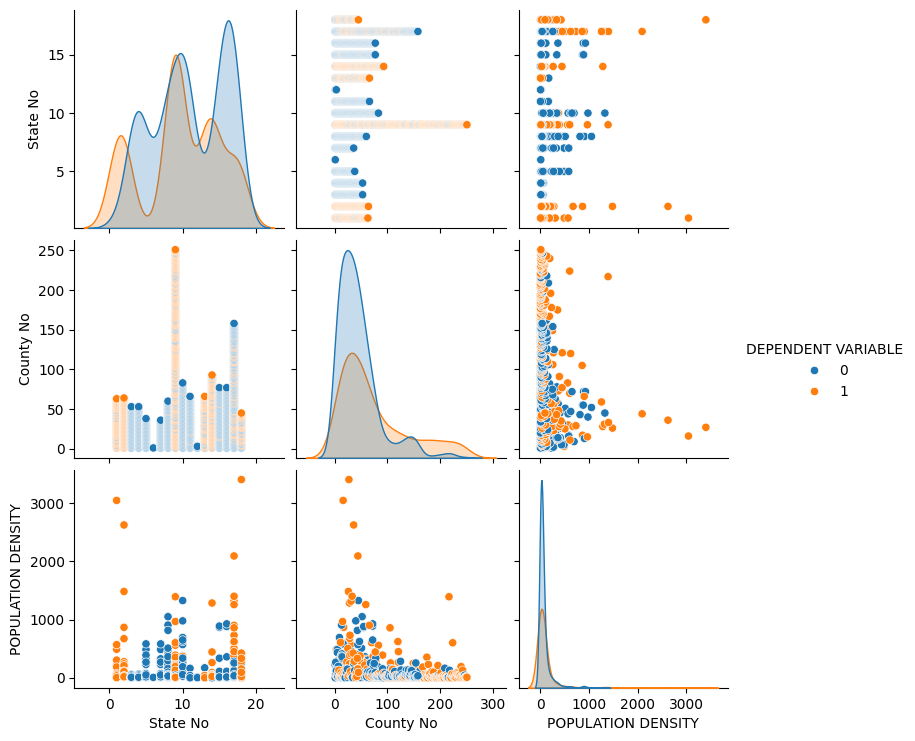

In [28]:
# Lets do some pair plots
subset = eval_set[['State No','County No', 'POPULATION DENSITY','DEPENDENT VARIABLE']]
sns.pairplot(data=subset, hue='DEPENDENT VARIABLE')
plt.show()
#


I am trying desperately to understand what I am looking at here (above).  To clear the view, I have limited the above set of scatter plots (the pair plot set) to variables that have something to do with location.  I think what I am seeing here is that certain states have a tendency toward one or another dependent variable.  Specifically, the Polulation density vs State one (bottom left) If i read that correctly, I am seeing the lower density states are more likely to be blue vs the higher density states which tend orange.  I am going to take a wild guess that the higher density states (of which there are fewer) tend to vote liberally, meaning they are for legalized gambling in general, where the lower density states tend to lean against.

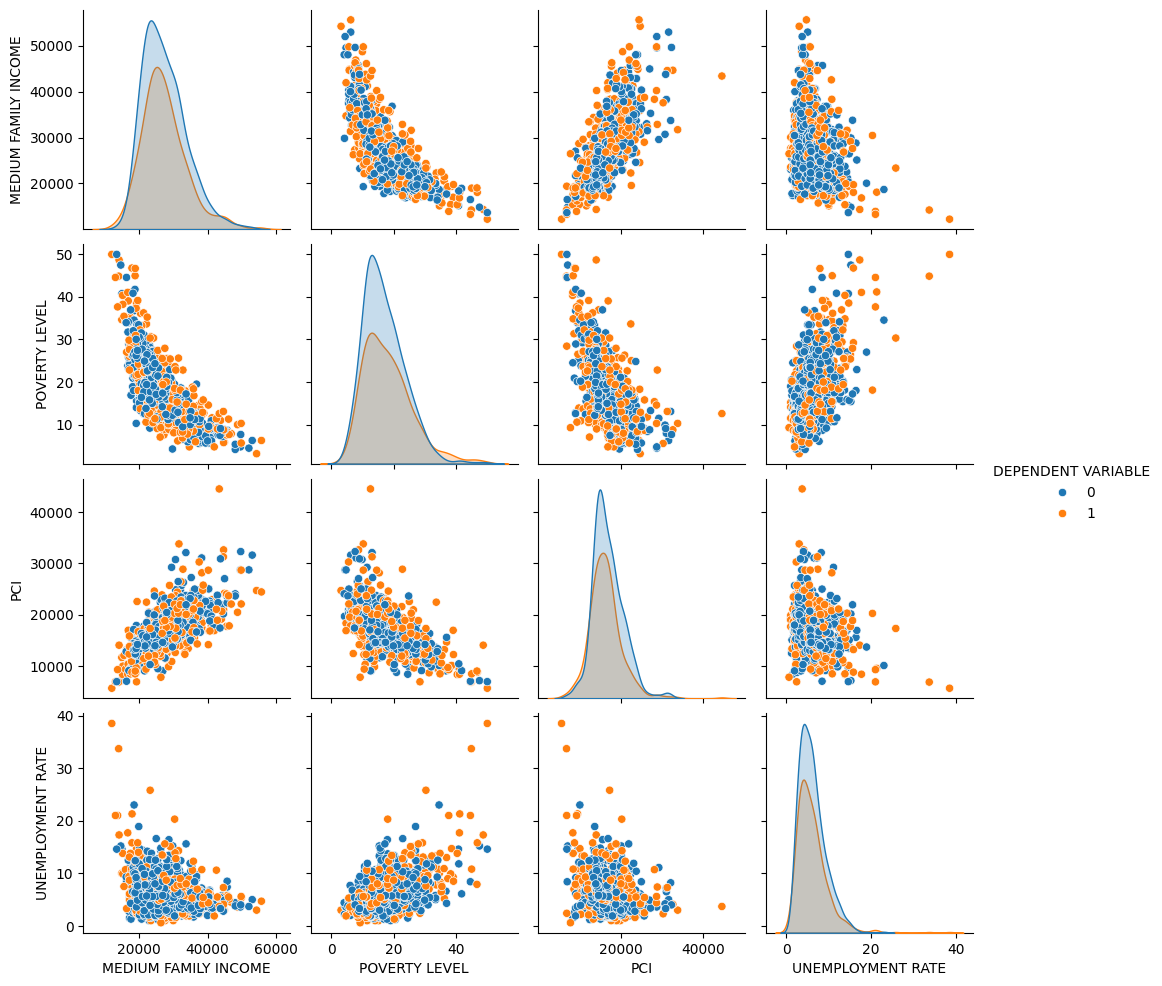

In [29]:
# lets try another one (income based)
subset = eval_set[['MEDIUM FAMILY INCOME','POVERTY LEVEL', 'PCI','UNEMPLOYMENT RATE','DEPENDENT VARIABLE']]
sns.pairplot(data=subset, hue='DEPENDENT VARIABLE')
plt.show()

This set looks pretty well mixed to me.  I guess if I had to say anything perhaps it is that when the employment rate is high, the chart tends orange.  If my previous guess was correct, perhaps this means there's more unemployment in denser areas and both of those factors lead to orange leaning attitudes towards gambling?

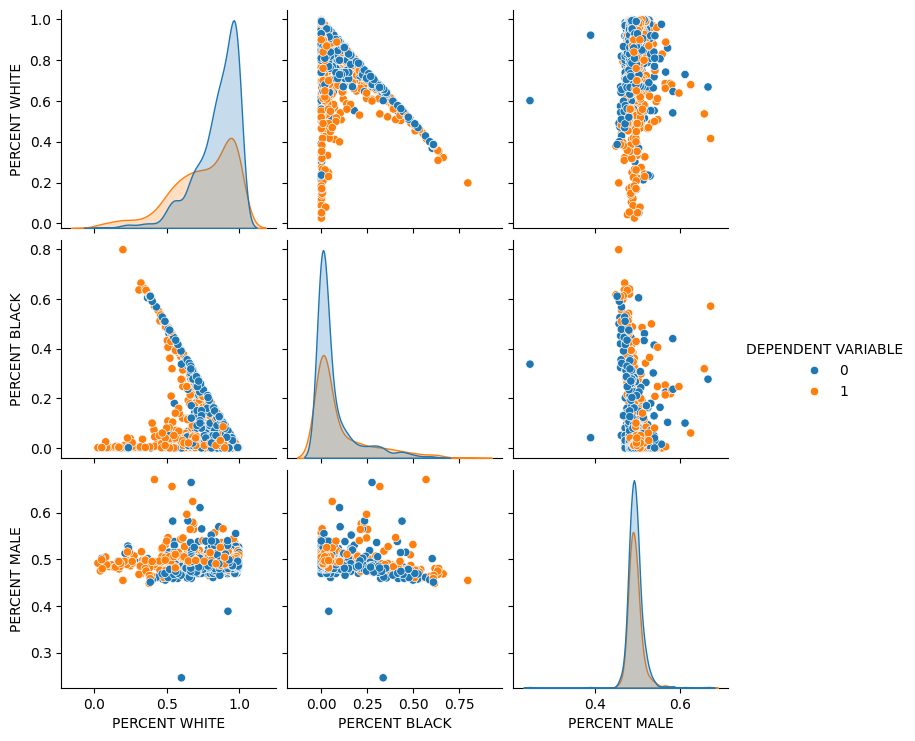

In [32]:
# how about race/gender?
subset = eval_set[['PERCENT WHITE','PERCENT BLACK', 'PERCENT MALE','DEPENDENT VARIABLE']]
sns.pairplot(data=subset, hue='DEPENDENT VARIABLE')
plt.show()

I aske ChatGPT whether urban or city dwellers tend to be more for or agains legalized gambling.  it said City people were more likely for it.  For that reason, I am assuming that 1 or orange in our graphs represents people who ar for it.<br/>With that in mind, this set of graphs seems to indicate that men are more supportive of gambling as are white people.  (Note, I could totally be reading this wrong I don't really understand it)

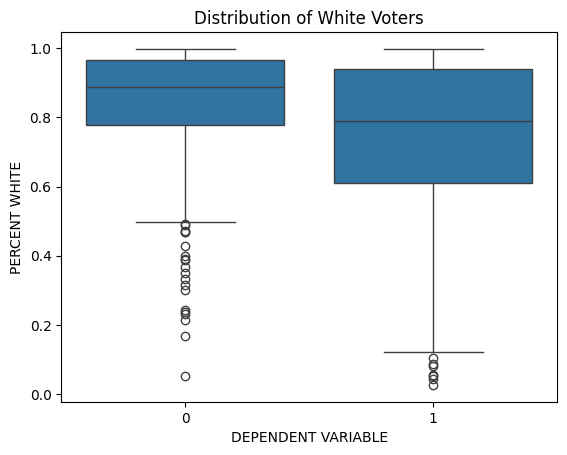

In [38]:
# I am curious about the breakdown of opinions between black vs white voters
snsplot = sns.boxplot(data=eval_set, x='DEPENDENT VARIABLE', y='PERCENT WHITE')
snsplot.set_title('Distribution of White Voters')
plt.show()

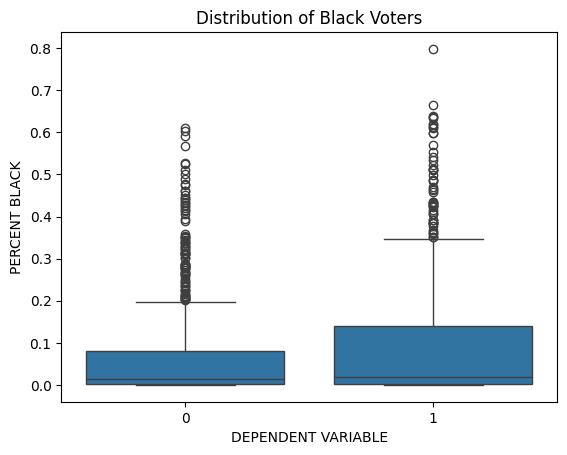

In [39]:
snsplot = sns.boxplot(data=eval_set, x='DEPENDENT VARIABLE', y='PERCENT BLACK')
snsplot.set_title('Distribution of Black Voters')
plt.show()

While that was an interesting experiment.  I couldn't begin to tell you what the heck any of it means?  